# Entity plotting

In [1]:
import mammos_units as u
import matplotlib.pyplot as plt
import numpy as np

import mammos_entity as me

Unit-aware plotting of `Entity` and `Quantity` objects can be activated using the :py:func:`~mammos_entity.enable_plotting` function and is off by default. This can be used in a restricted context using the `with` statement (see [here](https://docs.python.org/3/reference/compound_stmts.html#the-with-statement) to understand the `with` statement), as for example:

```python
with me.enable_plotting():
    plt.plot(...)
```

Alternatively, it can be enabled for the whole notebook (or Python script) by running the following:

In [2]:
me.enable_plotting()

In [3]:
T = me.Entity("ThermodynamicTemperature", [200, 300, 400], "K")
M_1 = me.Entity("Magnetization", [300, 200, 100], "kA/m")
M_2 = me.Entity("Magnetization", [0.4, 0.35, 0.3], "MA/m")
B = me.Entity("MagneticFluxDensity", [250, 250, 250], "mT")

## Same entity, different unit

We can plot multiple entities in the same plot. The units are converted automatically.

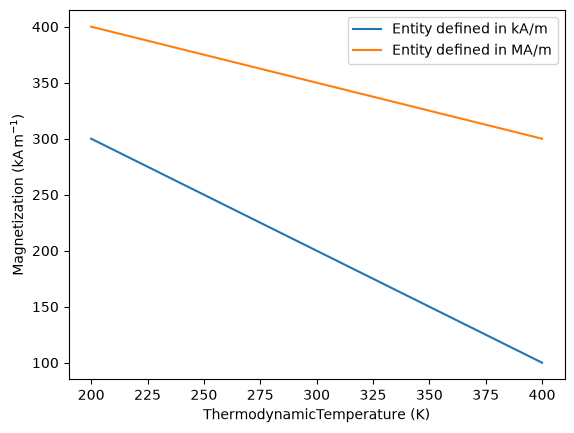

In [4]:
plt.plot(T, M_1, label="Entity defined in kA/m")
plt.plot(T, M_2, label="Entity defined in MA/m")
plt.legend()

## Reversing the order

The axis will take the ontology label and the unit of the first plotted entity-like object.

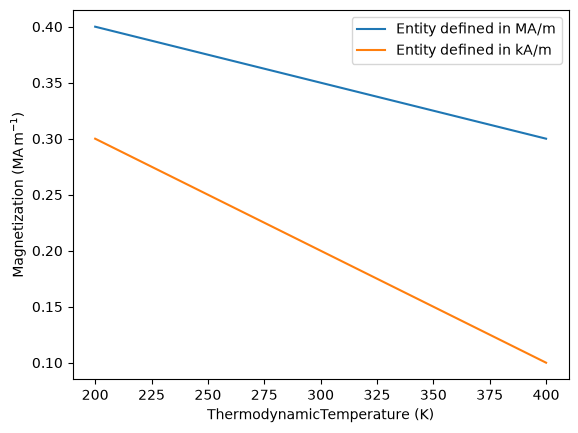

In [5]:
plt.plot(T, M_2, label="Entity defined in MA/m")
plt.plot(T, M_1, label="Entity defined in kA/m")
plt.legend()

## Plotting Entities, Quantities, and NumPy Arrays together

Plots allow the use of `Entity`, `Quantity`, and `Array` objects together. As NumPy arrays have no units, they are always assumed to be in the correct unit as the first plotted object.

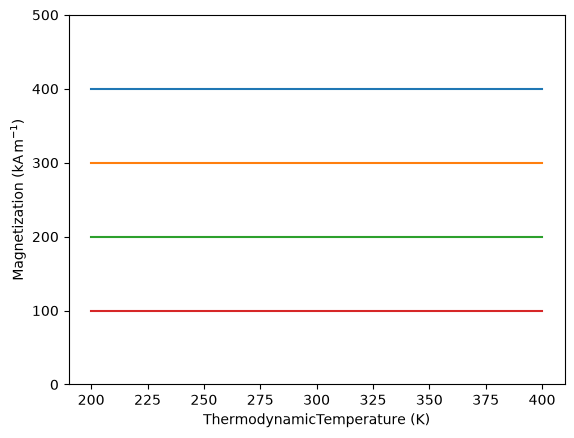

In [6]:
fig, ax = plt.subplots()
ax.plot(me.Entity("ThermodynamicTemperature", [200, 300, 400]), me.Entity("Magnetization", [400, 400, 400], "kA/m"))
ax.plot([200, 300, 400] * u.K, [300, 300, 300] * u.kA / u.m)
ax.plot(np.array([200, 300, 400]), np.array([200, 200, 200]))
ax.plot([200, 300, 400] * u.K, np.array([100, 100, 100]))
ax.set_ylim(0, 500);

But if the first one is not an entity, we lose the label:

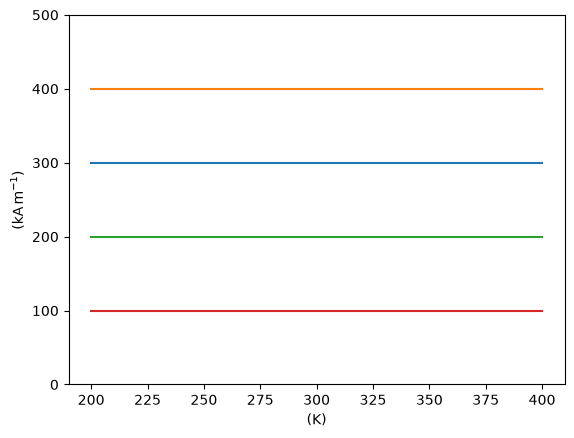

In [7]:
fig, ax = plt.subplots()
ax.plot([200, 300, 400] * u.K, [300, 300, 300] * u.kA / u.m)
ax.plot(me.Entity("ThermodynamicTemperature", [200, 300, 400]), me.Entity("Magnetization", [400, 400, 400], "kA/m"))
ax.plot(np.array([200, 300, 400]), np.array([200, 200, 200]))
ax.plot([200, 300, 400] * u.K, np.array([100, 100, 100]))
ax.set_ylim(0, 500);

## Conversion errors
When the entities have incompatible units, we get a `ConversionError`.

ConversionError: Failed to convert value(s) to axis units: <Quantity [250., 250., 250.] mT>

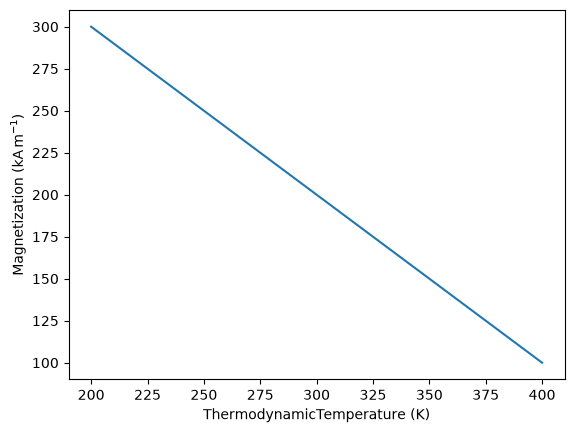

In [8]:
# Conversion error: M_1 is in 'kA/m' and B.q is in 'T'
plt.plot(T, M_1)
plt.plot(T, B.q)

We can of course activate Astropy's equivalencies before plotting:

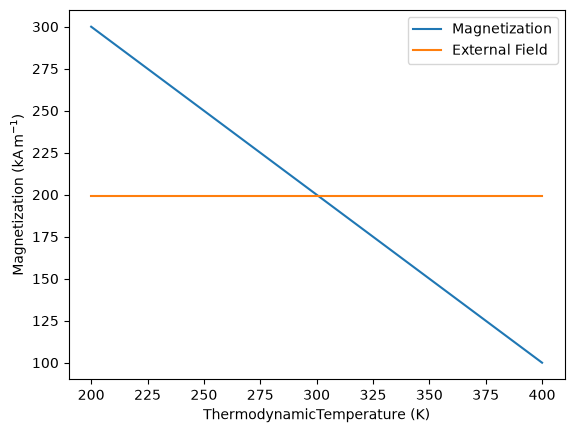

In [9]:
with u.set_enabled_equivalencies(u.magnetic_flux_field()):
    plt.plot(T, M_1, label="Magnetization")
    plt.plot(T, B.q, label="External Field")
    plt.legend()

Observe that plotting entities with different ontology labels will always raise an error. In this case the only possible solution is to plot the quantities.

ConversionError: Failed to convert value(s) to axis units: _EntityArray(MagneticFluxDensity, [250. 250. 250.], mT)

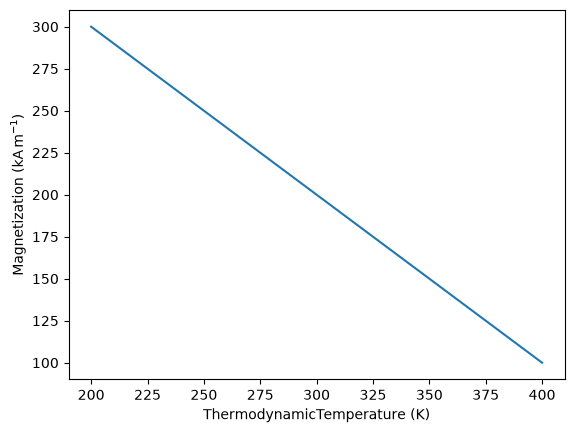

In [10]:
# Conversion error: M_1 has label 'Magnetization' and B has label 'MagneticFluxDensity'
plt.plot(T, M_1)
plt.plot(T, B)

Note:
We can include both the `enable_plotting` and the equivalencies in one `with` statement:

```python
with me.enable_plotting(), u.set_enabled_equivalencies(u.magnetic_flux_field()):
    plt.plot(T, M_1)
    plt.plot(T, B)
```

## Dimensionless quantities

The plotting setting allows `dimensionaless` entities and quantities, too. In this case the axis's label will contain no units.

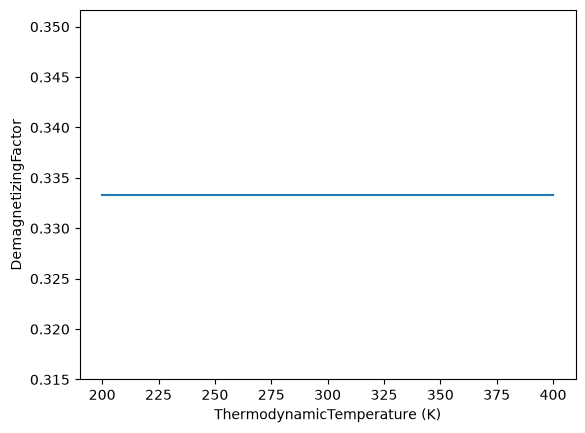

In [11]:
plt.plot(T, me.Entity("DemagnetizingFactor", [1 / 3, 1 / 3, 1 / 3]))

## Scaling in units

Astropy allows defining scaling powers in the unit. Plots always rescale units to have no power, as shown in the next two plots.

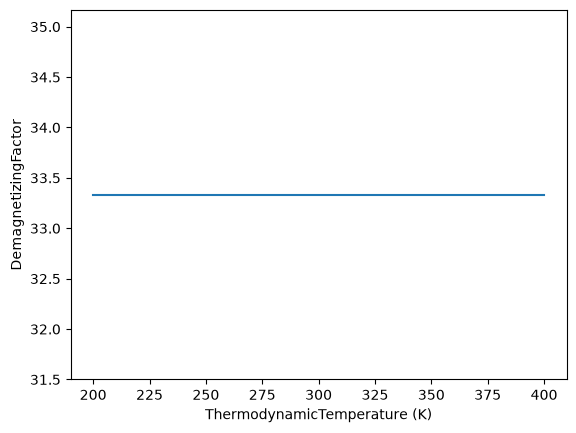

In [12]:
plt.plot(T, me.Entity("DemagnetizingFactor", [1 / 3, 1 / 3, 1 / 3], "1e2"))

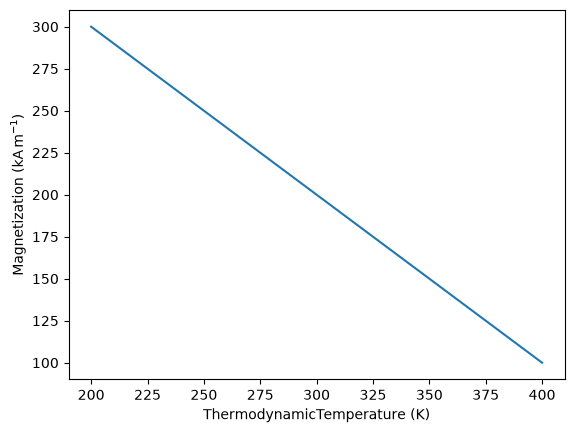

In [13]:
plt.plot(T, me.Entity("Magnetization", [0.3, 0.2, 0.1], "1000 kA/m"))